In [1]:
import pandas as pd
# Dış ortam hava durumu verisi okuma
df_hava = pd.read_csv('../data/meteo.csv')
# Verinin ilk 5 satırını yazdır
df_hava.head()

,time,AbsHumOut,Iglob,PARout,Pyrgeo,RadSum,Rain,Rhout,Tout,Winddir,Windsp
0,8/14/2018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,8/14/2018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,8/14/2018,13.369189,0.0,0.0,-32.000000,0.0,0.0,87.8,17.7,32.0,3.2
3,8/14/2018,13.389380,0.0,0.0,-36.000000,0.0,0.0,87.4,17.8,32.0,3.2
4,8/14/2018,13.455197,0.0,1.0,-38.999999,0.0,0.0,87.3,17.9,32.0,3.2


In [2]:
# Veri seti hakkında genel bilgiler
print("Veri Seti Bilgileri:")
df_hava.info()
# Hangi sütunda kaç tane boş (NaN) veri var
print("\nBoş Veri (NaN) Sayıları:")
print(df_hava.isnull().sum())

# İçinde NaN bulunan ilk hatalı satırları veri setinden sil
df_hava_temiz = df_hava.dropna()

# Temizlenmiş verinin ilk 5 satırı
df_hava_temiz.head()

Veri Seti Bilgileri:
<class 'pandas.DataFrame'>
RangeIndex: 33133 entries, 0 to 33132
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   time       33133 non-null  str    
 1   AbsHumOut  32991 non-null  float64
 2   Iglob      32992 non-null  float64
 3   PARout     32992 non-null  float64
 4   Pyrgeo     32992 non-null  float64
 5   RadSum     32991 non-null  float64
 6   Rain       32992 non-null  float64
 7   Rhout      32991 non-null  float64
 8   Tout       32991 non-null  float64
 9   Winddir    32992 non-null  float64
 10  Windsp     32991 non-null  float64
dtypes: float64(10), str(1)
memory usage: 2.8 MB

Boş Veri (NaN) Sayıları:
time           0
AbsHumOut    142
Iglob        141
PARout       141
Pyrgeo       141
RadSum       142
Rain         141
Rhout        142
Tout         142
Winddir      141
Windsp       142
dtype: int64


,time,AbsHumOut,Iglob,PARout,Pyrgeo,RadSum,Rain,Rhout,Tout,Winddir,Windsp
2,8/14/2018,13.369189,0.0,0.0,-32.000000,0.0,0.0,87.8,17.7,32.0,3.2
3,8/14/2018,13.389380,0.0,0.0,-36.000000,0.0,0.0,87.4,17.8,32.0,3.2
4,8/14/2018,13.455197,0.0,1.0,-38.999999,0.0,0.0,87.3,17.9,32.0,3.2
5,8/14/2018,13.465462,0.0,1.0,-28.000001,0.0,0.0,87.9,17.8,32.0,3.2
6,8/14/2018,13.435029,0.0,1.0,-23.000000,0.0,0.0,87.7,17.8,32.0,3.2


In [3]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Modelin kullanacağı sayısal kolonları seç
features = ['Tout', 'Rhout', 'RadSum']
# Tout: Sıcaklık, Rhout: Nem, RadSum: Radyasyon
data_to_scale = df_hava_temiz[features].values

# MinMaxScaler ile verileri 0 ile 1 arasına sıkıştırma
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data_to_scale)

print("Ölçeklendirilmiş verinin ilk satırı:", scaled_data[0])

# Pencereleme (Windowing) Fonksiyonu
def create_sequences(data, seq_length):
    X = []
    y = []
    for i in range(len(data) - seq_length):
        # seq_length kadar geçmiş veri (X)
        X.append(data[i:(i + seq_length)])
        # Bir sonraki adımın verisi (y) - Şimdilik sıcaklığı (Tout) varsayıyoruz
        y.append(data[i + seq_length, 0])
    return np.array(X), np.array(y)

# Geçmiş 12 adımı (veri 5 dk aralıklıysa 12 adım = 1 saat) kullanarak 13. adımı tahmin edelim
SEQ_LENGTH = 12
X, y = create_sequences(scaled_data, SEQ_LENGTH)

print(f"\nX (Girdi) boyutu: {X.shape} -> (Örnek Sayısı, Zaman Adımı, Özellik Sayısı)")
print(f"y (Çıktı) boyutu: {y.shape} -> (Örnek Sayısı, Hedef Değişken)")

Ölçeklendirilmiş verinin ilk satırı: [0.6908397  0.84536082 0.        ]

X (Girdi) boyutu: (32979, 12, 3) -> (Örnek Sayısı, Zaman Adımı, Özellik Sayısı)
y (Çıktı) boyutu: (32979,) -> (Örnek Sayısı, Hedef Değişken)


In [6]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Veriyi Eğitim (%80) ve Test (%20) olarak böl
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

print(f"Eğitim verisi: {X_train.shape}")
print(f"Test verisi: {X_test.shape}")

# LSTM Modeli
model = Sequential()

# İlk LSTM katmanı
model.add(LSTM(units=64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.2)) # overfitting engellemek için %20 oranında nöronu rastgele kapat

# İkinci LSTM katmanı
model.add(LSTM(units=32))
model.add(Dropout(0.2))

# Çıkış katmanı
model.add(Dense(units=1))

# Modeli derleyelim
model.compile(optimizer='adam', loss='mean_squared_error')

# Özet tablo
model.summary()

Eğitim verisi: (26383, 12, 3)
Test verisi: (6596, 12, 3)


C:\Users\iclalolukkaya\PycharmProjects\OtonomSeraLSTM\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 12, 64)         │        17,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
825/825 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.0059 - val_loss: 4.4602e-04
Epoch 2/20
825/825 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0023 - val_loss: 4.0548e-04
Epoch 3/20
825/825 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0015 - val_loss: 9.5479e-05
Epoch 4/20
825/825 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 9.7252e-04 - val_loss: 1.1221e-04
Epoch 5/20
825/825 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 6.7617e-04 - val_loss: 5.1683e-04
Epoch 6/20
825/825 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 5.1140e-04 - val_loss: 4.6182e-04
Epoch 7/20
825/825 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 4.5305e-04 - val_loss: 5.5269e-05
Epoch 8/20
825/825 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 4.4408e-04 - val_loss: 8.7257e-05
Epoch 9/20
825/825 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 4.4259e-04 - val_loss: 6.9165e-05
Epoch 10/20
825/825 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 4.2593e-04 - val_loss: 1.3129e-04
Epoch 11/20
825/825 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 4.1409e-04

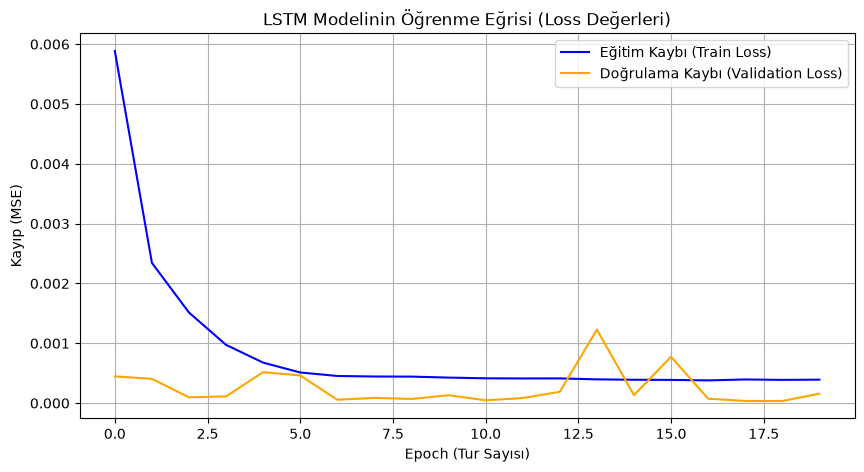

In [7]:
import matplotlib.pyplot as plt

# Model eğitimi
EPOCHS = 20
BATCH_SIZE = 32

history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test, y_test),
    verbose=1
)

# Eğitim ve Doğrulama Kayıp (Loss) Grafiği
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Eğitim Kaybı (Train Loss)', color='blue')
plt.plot(history.history['val_loss'], label='Doğrulama Kaybı (Validation Loss)', color='orange')
plt.title('LSTM Modelinin Öğrenme Eğrisi (Loss Değerleri)')
plt.xlabel('Epoch (Tur Sayısı)')
plt.ylabel('Kayıp (MSE)')
plt.legend()
plt.grid(True)
plt.show()